### Random Forest Algorithm using Tensorflow

##### Απαραίτητες Βιβλιοθήκες

In [61]:
import tensorflow_decision_forests as tfdf

import numpy as np
import pandas as pd
import tensorflow as tf
import tf_keras
import math

# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.8.1


##### Διάβασμα dataset και Δημιουργία Dataframe

In [62]:
path_train = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/train data.csv"  
train_data = pd.read_csv(path_train, delimiter=';')

path_test = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/test data.csv"  
test_data = pd.read_csv(path_test, delimiter=';')

label_column = "class" 

tf_train_dataset = tfdf.keras.pd_dataframe_to_tf_dataset(train_data, label=label_column)
tf_test_dataset = tfdf.keras.pd_dataframe_to_tf_dataset(test_data, label=label_column)

##### Train το Μοντέλο

In [63]:
model_rf = tfdf.keras.RandomForestModel(verbose=0)
model_rf.fit(tf_train_dataset, validation_data=tf_test_dataset)

Num validation examples: tf.Tensor(100, shape=(), dtype=int32)


[INFO 24-02-20 13:46:10.7422 EET kernel.cc:1233] Loading model from path /tmp/tmpmw5w81f1/model/ with prefix d59af300f1334a27
[INFO 24-02-20 13:46:10.7579 EET decision_forest.cc:660] Model loaded with 300 root(s), 7624 node(s), and 30 input feature(s).
[INFO 24-02-20 13:46:10.7579 EET abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 24-02-20 13:46:10.7579 EET kernel.cc:1061] Use fast generic engine


In [64]:
#model_rf.summary()

inspector = model_rf.make_inspector()
importances = inspector.variable_importances()

print("Variable Importances:")
for variable, importance in importances.items():
    print(f"{variable}: {importance}")

Variable Importances:
INV_MEAN_MIN_DEPTH: [("range_3" (1; #29), 0.2906421428065502), ("range_2" (1; #28), 0.26190346385072244), ("range_4" (1; #30), 0.25426609720873733), ("range_1" (1; #27), 0.2521360519278209), ("I1MIN" (1; #2), 0.22073932625632628), ("I2VAR" (1; #7), 0.21950819807534638), ("I1VAR" (1; #3), 0.2085086241303701), ("I1" (1; #0), 0.2081324478067766), ("I2MIN" (1; #6), 0.20377696970381096), ("I3var" (1; #11), 0.20255967223249602), ("I2" (1; #4), 0.19982764833946892), ("Vdcmax1" (1; #23), 0.1924512777226497), ("I4" (1; #12), 0.19214231024097655), ("I3" (1; #8), 0.19195454834826703), ("I4MIN" (1; #14), 0.19033387315208058), ("Vdcmin1" (1; #25), 0.19000145442967104), ("T" (1; #22), 0.18949863094330707), ("I3max" (1; #9), 0.18940447002822045), ("Pdcmean1" (1; #21), 0.1893139156719629), ("Vdcmean1" (1; #24), 0.18901139677375323), ("Itotalmax1" (1; #19), 0.1887890651518098), ("I2MAX" (1; #5), 0.18877308380979507), ("I6" (1; #16), 0.18866701972265001), ("Itotalmin1" (1; #20), 0.

##### Αξιολόγηση Μοντέλου

In [65]:
model_rf.compile(metrics=["accuracy"]) 
evaluation = model_rf.evaluate(tf_test_dataset, return_dict=True)
print()

for name, value in evaluation.items():
  print(f"{name}: {value:.4f}")


1/1 [==============================] - 0s 126ms/step - loss: 0.0000e+00 - accuracy: 0.9100

loss: 0.0000
accuracy: 0.9100


##### Self-Evaluation

In [66]:
model_rf.make_inspector().evaluation()

Evaluation(num_examples=600, accuracy=1.0, loss=0.03632503500363479, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

#### Plot το Μοντέλο

In [67]:
model_rf.make_inspector().training_logs()

[TrainLog(num_trees=1, evaluation=Evaluation(num_examples=218, accuracy=1.0, loss=0.0, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=11, evaluation=Evaluation(num_examples=595, accuracy=0.9949579831932773, loss=0.03512447741853089, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=21, evaluation=Evaluation(num_examples=600, accuracy=0.9983333333333333, loss=0.05204623283197483, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=31, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.043010135057071845, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=41, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.043810393487413724, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_trees=51, evaluation=Evaluation(num_examples=600, accuracy=1.0, loss=0.039169912735621135, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)),
 TrainLog(num_tree

1/1 [==============================] - 0s 101ms/step - loss: 0.0000e+00 - accuracy: 0.9100


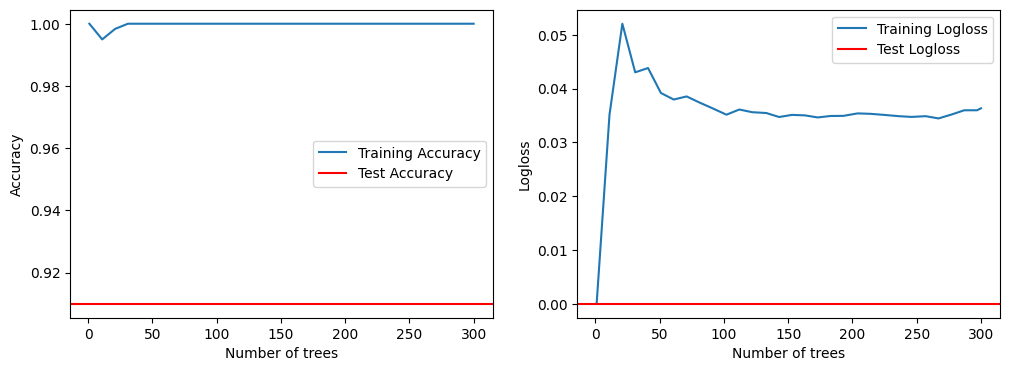

In [68]:
import matplotlib.pyplot as plt

train_logs = model_rf.make_inspector().training_logs()
evaluation = model_rf.evaluate(tf_test_dataset, return_dict=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.accuracy for log in train_logs], label='Training Accuracy')
plt.axhline(evaluation['accuracy'], color='red', linestyle='-', label='Test Accuracy')
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.loss for log in train_logs], label='Training Logloss')
plt.axhline(evaluation['loss'], color='red', linestyle='-', label='Test Logloss')
plt.xlabel("Number of trees")
plt.ylabel("Logloss")
plt.legend()

plt.show()

### Tensorboard

In [69]:
# This cell start TensorBoard that can be slow.
# Load the TensorBoard notebook extension
%load_ext tensorboard
# Google internal version
# %load_ext google3.learning.brain.tensorboard.notebook.extension


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [70]:
# Clear existing results (if any)
#rm -fr "/tmp/tensorboard_logs"

In [71]:
# Export the meta-data to tensorboard.
model_rf.make_inspector().export_to_tensorboard("/tmp/tensorboard_logs")

In [72]:
# docs_infra: no_execute
# Start a tensorboard instance.
%tensorboard --logdir "/tmp/tensorboard_logs"

Reusing TensorBoard on port 6007 (pid 4505), started 0:36:55 ago. (Use '!kill 4505' to kill it.)

#### Re-train the model with a different dataset(Range_1, Range_2, Range_3, Range_4)

In [73]:
feature_1 = tfdf.keras.FeatureUsage(name="range_1")
feature_2 = tfdf.keras.FeatureUsage(name="range_2")
feature_3 = tfdf.keras.FeatureUsage(name="range_3")
feature_4 = tfdf.keras.FeatureUsage(name="range_4")

all_features = [feature_1, feature_2, feature_3, feature_4]

model_rf_2 = tfdf.keras.RandomForestModel(features=all_features, exclude_non_specified_features=True, verbose=0)

model_rf_2.compile(metrics=["accuracy"])
model_rf_2.fit(tf_train_dataset, validation_data=tf_test_dataset)

print()
print(model_rf_2.evaluate(tf_test_dataset, return_dict=True))

Num validation examples: tf.Tensor(100, shape=(), dtype=int32)


[INFO 24-02-20 13:46:11.8124 EET kernel.cc:1233] Loading model from path /tmp/tmp6z8_qfgb/model/ with prefix a13685f341fe425f
[INFO 24-02-20 13:46:11.8168 EET decision_forest.cc:660] Model loaded with 300 root(s), 2352 node(s), and 4 input feature(s).
[INFO 24-02-20 13:46:11.8168 EET kernel.cc:1061] Use fast generic engine



1/1 [==============================] - 0s 76ms/step - loss: 0.0000e+00 - accuracy: 0.9500
{'loss': 0.0, 'accuracy': 0.949999988079071}


#### Plot το Μοντέλο

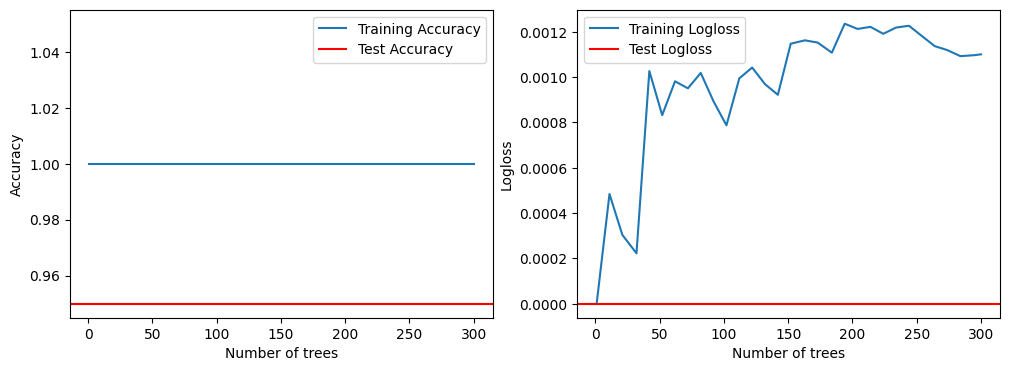

In [75]:
import matplotlib.pyplot as plt

train_logs = model_rf_2.make_inspector().training_logs()
#evaluation = model_rf_2.evaluate(tf_test_dataset, return_dict=True)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.accuracy for log in train_logs], label='Training Accuracy')
plt.axhline(evaluation['accuracy'], color='red', linestyle='-', label='Test Accuracy')
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in train_logs], [log.evaluation.loss for log in train_logs], label='Training Logloss')
plt.axhline(evaluation['loss'], color='red', linestyle='-', label='Test Logloss')
plt.xlabel("Number of trees")
plt.ylabel("Logloss")
plt.legend()

plt.show()

### Tensorboard

In [80]:
# This cell start TensorBoard that can be slow.
# Load the TensorBoard notebook extension
%load_ext tensorboard
# Google internal version
# %load_ext google3.learning.brain.tensorboard.notebook.extension

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [81]:
# Clear existing results (if any)
#rm -fr "/tmp/tensorboard_logs"

In [82]:
# Export the meta-data to tensorboard.
model_rf_2.make_inspector().export_to_tensorboard("/tmp/tensorboard_logs")

In [83]:
# docs_infra: no_execute
# Start a tensorboard instance.
%tensorboard --logdir "/tmp/tensorboard_logs"

Reusing TensorBoard on port 6007 (pid 4505), started 0:45:37 ago. (Use '!kill 4505' to kill it.)